## AP50 for small amounts of target

In [7]:
import os
import pandas as pd

# Replace 'your_file.txt' with the path to your text file
print(os.getcwd())
#file_path = '../../urchin_syn.txt'
file_path = "../../synthetic_as_aug_v1_avg.txt" # Rows: UDD (10) followed by IMOS AUV (10), Cols: No, Yes
# Read the file into a DataFrame
df = pd.read_csv(file_path, delimiter='\t', header=None)
df.columns = ["No of Target", "No", "Yes"]
#df = df.iloc[:, 1:]

df["Dataset"] = ["UDD"] * 8 + ["IMOS AUV"] * 9
df = df[["Dataset"] + list(df.columns[:-1])]

/Users/heather/GitHub/infinigenBenthic/scripts/benthic


In [8]:
# Display the DataFrame
#columns=['UDD-None','IMOS-None','UDD-NoUDA','IMOS-NoUDA','UDD-MT','IMOS-MT','UDD-ALDI','IMOS-ALDI']
#df.columns = columns

#df_melted = pd.melt(df, var_name='Test-Method', value_name="AP50")
df_melted = pd.melt(df, id_vars=df.columns[:2], value_vars=df.columns[2:], var_name='Augmented with Synthetic Data', value_name='AP50')

num_rows, num_cols = df.shape
print(num_rows, num_cols)

#df_melted['N'] = [0, 100, 200, 400, 600] * num_cols
#df_melted['Data'] = (['UDD'] * num_rows + ['IMOS AUV'] * num_rows) * int(num_cols/2)

17 4


In [9]:
#df_melted['With/Without Synthetic + UDA method'] = ['without Synthetic'] * num_rows*2 + ['with Synthetic'] * num_rows*2 + ['with Synthetic + Mean Teacher'] * num_rows*2 + ['with Synthetic + ALDI'] * num_rows*2
df_melted.reset_index(drop=True, inplace=True)
df = df_melted
#df = df_melted.iloc[:, [3,4,2,1]]

#df = df.sort_values(by=['Data', 'With/Without Synthetic + UDA method'], ascending=[False, True])

In [274]:
#df = df[df['With/Without Synthetic + UDA method'] != 'with Synthetic + ALDI']
#df = df[df['With/Without Synthetic + UDA method'] != 'with Synthetic + Mean Teacher']

In [275]:
df['With/Without Synthetic + UDA method'] not in ['with Synthetic + ALDI', 'with Synthetic + Mean Teacher']

KeyError: 'With/Without Synthetic + UDA method'

/opt/miniconda3/envs/pytorchplus38/lib/python3.8/site-packages/seaborn/axisgrid.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/opt/miniconda3/envs/pytorchplus38/lib/python3.8/site-packages/seaborn/axisgrid.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


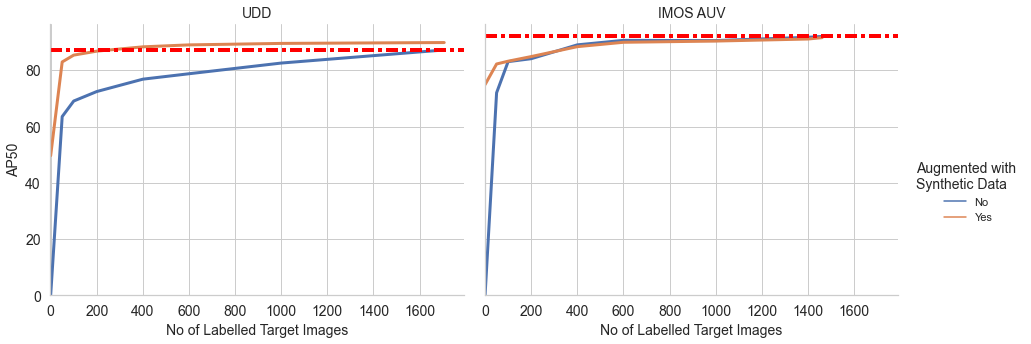

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Apply the default theme
sns.set_theme(style="whitegrid")
g = sns.relplot(
    data=df, 
    x='No of Target', y='AP50', col='Dataset', 
    hue='Augmented with Synthetic Data', 
    kind='line', 
    markers=["o", "<", ">", "*"], 
    #style='Synthetic Data', 
    linewidth=3,
    aspect=1.4,
    height=5,
    facet_kws={'gridspec_kws': {'wspace': 0.05, 'hspace': 0.05}})
#g.set(xscale='log')

# Add titles and labels

# Define y-values for horizontal lines for each subplot
y_values = {'UDD': 86.9, 'IMOS': 92.3}
y_values = {'UDD': 87.2, 'IMOS': 92.0}

# Add horizontal lines to each subplot
for ax, category in zip(g.axes.flat, y_values):
    ax.axhline(y=y_values[category], color='red', linestyle=(0, (3, 1, 1, 1)), linewidth=4)
plt.ylim(0, None)
plt.xlim(-2, None)

# Move the legend to the right of the plot
# Show the plot

g.set_axis_labels("No of Labelled Target Images", "AP50", fontsize=14)
g.set_titles("{col_name}", size=14)
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
#g.set_ylabel('AP50', fontsize=16)
g._legend.set_title('Augmented with \nSynthetic Data')
for text in g._legend.get_texts():
    text.set_fontsize(14)
g._legend.get_title().set_fontsize(14)

sns.move_legend(g, "lower center", bbox_to_anchor=(0.9, 0.3))

plt.show()
fig = g.fig
fig.savefig('synthetic_as_aug.jpg', dpi=200)

#### AP50 by training method by dataset

In [6]:
import os
import pandas as pd

# Replace 'your_file.txt' with the path to your text file
print(os.getcwd())
file_path = '../../basic_results.txt'
# Read the file into a DataFrame
df = pd.read_csv(file_path, delimiter='&')
df = df.iloc[:, 1:]


/Users/heather/GitHub/infinigenBenthic/scripts/benthic


In [7]:

df = pd.melt(df, var_name='Data', value_name="AP50")
df['Method'] = ['Base - Weak', 'Base - Strong', 'Mean Teacher', 'ALDI++'] *2


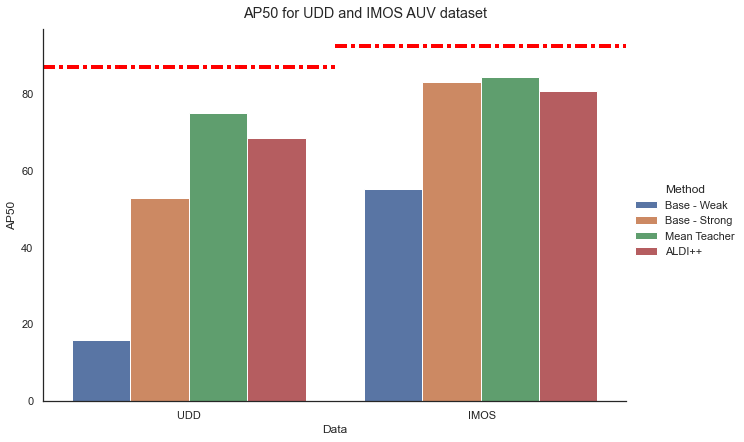

In [8]:
# Create a bar plot with seaborn
sns.set_theme(style="white")
g = sns.catplot(
    data=df, 
    x='Data', 
    y='AP50', 
    hue='Method', 
    kind='bar', 
    height=6, 
    aspect=1.5
)
plt.axhline(y=86.9, color='red', linestyle=(0, (3, 1, 1, 1)), linewidth=4, xmin=0.0, xmax=0.5)
plt.axhline(y=92.3, color='red', linestyle=(0, (3, 1, 1, 1)), linewidth=4, xmin=0.5, xmax=1.0)

# Set the title of the plot
g.fig.suptitle('AP50 for UDD and IMOS AUV dataset', y=1.02)

# Show the plot
plt.show()


## Adding real data to synthetic


In [96]:
import os
import pandas as pd

# Replace 'your_file.txt' with the path to your text file
print(os.getcwd())
#file_path = '../../urchin_syn.txt'
file_path = "../../ALDI-DOAD_master.csv" # Rows: UDD (10) followed by IMOS AUV (10), Cols: No, Yes
# Read the file into a DataFrame
df = pd.read_csv(file_path, delimiter=',')

/Users/heather/GitHub/infinigenBenthic/scripts/benthic


/opt/miniconda3/envs/pytorchplus38/lib/python3.8/site-packages/seaborn/axisgrid.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/opt/miniconda3/envs/pytorchplus38/lib/python3.8/site-packages/seaborn/axisgrid.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


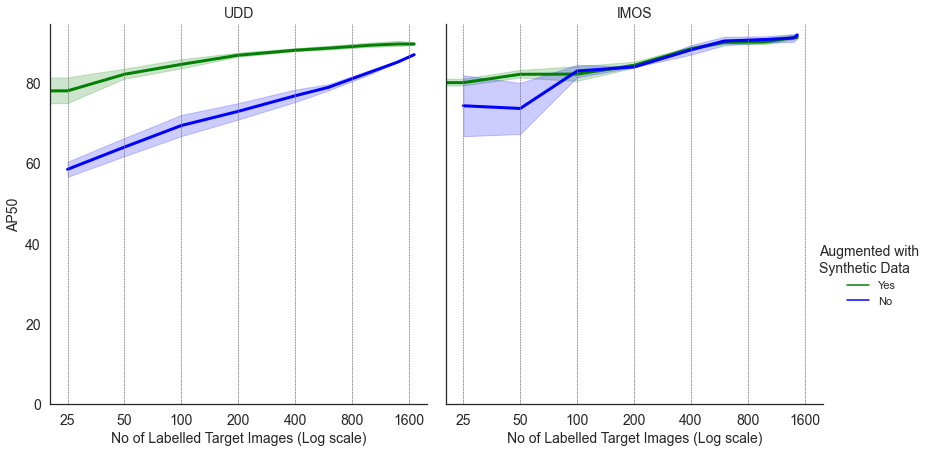

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

# Apply the default theme
sns.set_theme(style="white")
g = sns.relplot(
    data=df, 
    x='num_real_all', y='AP50', col='Data', 
    hue='Synthetic_data', 
    palette={"Yes": 'green', "No": 'blue'},
    kind='line', 
    ci="sd",
    markers=["o", "<", ">", "*"], 
    #style='Synthetic Data', 
    linewidth=3,
    aspect=0.9,
    height=7,
    facet_kws={'gridspec_kws': {'wspace': 0.05, 'hspace': 0.05}})
#g.set(xscale='log')

# Apply log scale to the x-axis for all facets
log_x_scale = True
if log_x_scale:
    for ax in g.axes.flat:
        ax.set_xscale('log', base=2)
    ticks = [25, 50, 100, 200, 400, 800, 1600]
else:
    ticks = [50, 100, 200, 500, 1000, 1500]
plt.xticks(ticks, [str(t) for t in ticks])
# Add titles and labels

# Define y-values for horizontal lines for each subplot
y_values = {'UDD': 86.9, 'IMOS': 92.3}
y_values = {'UDD': 87.15, 'IMOS': 92.0}


# Specify the tick markers on the x-axis


for ax in g.axes.flat:    
    #g.axes[0, 0].set_xticklabels(g.axes[0, 0].get_xticklabels(), rotation=45)
    #g.axes[0, 1].set_xticklabels(g.axes[0, 1].get_xticklabels(), rotation=45)

    # Add vertical lines at each tick marker
    for tick in ticks:
        g.axes[0, 0].axvline(x=tick, color='gray', linestyle='--', linewidth=0.5)
        g.axes[0, 1].axvline(x=tick, color='gray', linestyle='--', linewidth=0.5)

# Add horizontal lines to each subplot
#for ax, category in zip(g.axes.flat, y_values):
#    ax.axhline(y=y_values[category], color='red', linestyle=(0, (3, 1, 1, 1)), linewidth=4)
plt.ylim(0, None)
plt.xlim(None, 2000)

# Move the legend to the right of the plot
# Show the plot

g.set_axis_labels("No of Labelled Target Images (Log scale)", "AP50", fontsize=14)
g.set_titles("{col_name}", size=14)
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
#g.set_ylabel('AP50', fontsize=16)
g._legend.set_title('Augmented with \nSynthetic Data')
for text in g._legend.get_texts():
    text.set_fontsize(14)
g._legend.get_title().set_fontsize(14)


sns.move_legend(g, "lower center", bbox_to_anchor=(0.95, 0.3))

plt.show()
fig = g.fig
fig.savefig('synthetic_as_aug.jpg', dpi=200)

## AP50 by iteration


In [219]:
import pandas as pd
import os
import glob

# Replace 'your_directory_path' with the path to your directory
directory_path = '/Users/heather/GitHub/infinigenBenthic/ap50_by_iteration'

# Use glob to find all CSV files in the directory
csv_files = glob.glob(os.path.join(directory_path, '*.csv'))
header = [os.path.basename(p) for p in csv_files]
header = ["Base - Strong Aug", "Mean Teacher", "ALDI++", "Oracle", ]
# Print the list of CSV files
dfs = [pd.read_csv(file, header=None).T for file in csv_files]

df = pd.concat([df.iloc[-1,:] for df in dfs], ignore_index=True, axis=1)
df.columns = header

df = df.iloc[:,[3,0,1,2]]
print(df.shape)
# Create the new row with integers increasing from 0 to the number of columns
new_row = pd.DataFrame([[i*100+500 for i in range(df.shape[0])]]).T

# Concatenate the new row to the beginning of the DataFrame
df = pd.concat([new_row, df], ignore_index=True, axis=1)
df.columns = ["Iterations"] + header

(85, 4)


In [220]:
df = pd.melt(df, id_vars=['Iterations'], value_vars=header,
                    var_name='Training Method', value_name='AP50')

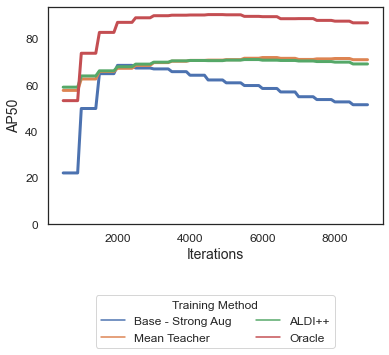

In [225]:
import seaborn as sns
import matplotlib.pyplot as plt

# Apply the default theme
sns.set_theme(style="white")
g = sns.lineplot(
    data=df, 
    x='Iterations',
    y='AP50',
    hue='Training Method', 
    #markers=["o", "<", ">", "*"], 
    #style='Training Method', 
    linewidth=3)

# Add titles and labels
#g.set_titles("{col_name}")
#g.set_axis_labels("No of Labelled Target Images", "AP50")
g.set_xlabel('Iterations', fontsize=14)
g.set_ylabel('AP50', fontsize=14)
g.tick_params(axis='both', which='major', labelsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, title='Training Method', fontsize=12, title_fontsize=12)
plt.ylim(0, None)


# Move the legend to the right of the plot
# Show the plot
#g.legend.set(title="With or Without Synthetic data")

plt.show()